In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_predict

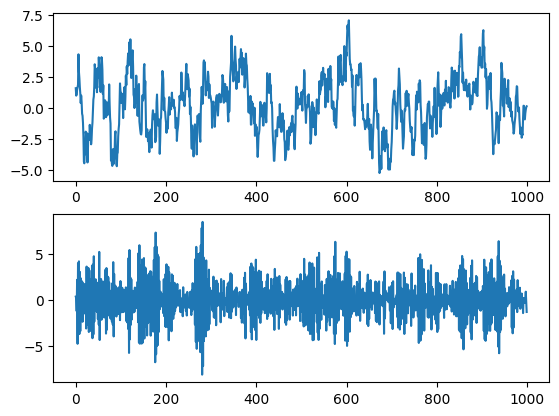

In [2]:
# Plot 1: AR parameter = +0.9
plt.subplot(2, 1, 1)
ar1 = np.array([1, -0.9])
ma1 = np.array([1])

AR_object1 = ArmaProcess(ar1, ma1)
simulated_data_1 = AR_object1.generate_sample(nsample = 1000)
plt.plot(simulated_data_1)

# Plot 2: AR parameter = -0.9
plt.subplot(2, 1, 2)
ar2 = np.array([1, 0.9])
ma2 = np.array([1])

AR_object2 = ArmaProcess(ar2, ma2)
simulated_data_2 = AR_object2.generate_sample(nsample = 1000)
plt.plot(simulated_data_2)
plt.show()

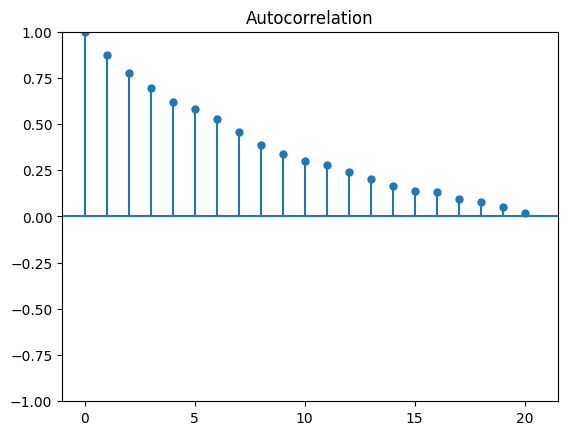

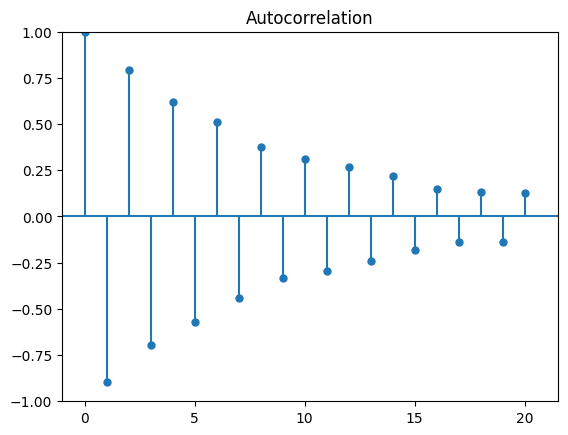

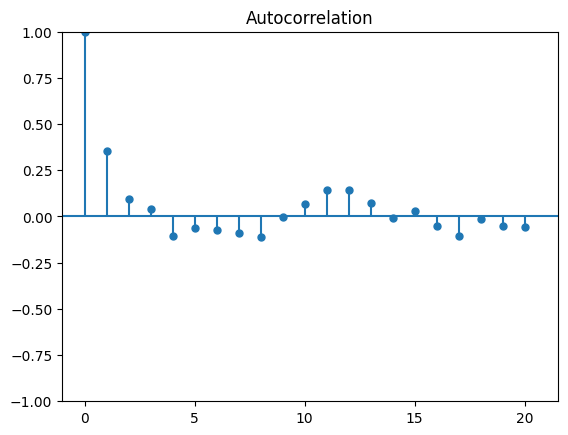

In [3]:
# Generate sample data
np.random.seed(42) # For reproducibility
n_samples = 200
ma = np.array([1])

ar_1 = np.array([1, -0.9])
ar_process_1 = ArmaProcess(ar_1, ma)
simulated_data_1 = ar_process_1.generate_sample(nsample = n_samples)

ar_2 = np.array([1, 0.9])
ar_process_2 = ArmaProcess(ar_2, ma)
simulated_data_2 = ar_process_2.generate_sample(nsample = n_samples)

ar_3 = np.array([1, -0.3])
ar_process_3 = ArmaProcess(ar_3, ma)
simulated_data_3 = ar_process_3.generate_sample(nsample = n_samples)

# Plot 1: AR parameter = +0.9
plot_acf(simulated_data_1, alpha = 1, lags = 20)
plt.show()

# Plot 2: AR parameter = -0.9
plot_acf(simulated_data_2, alpha = 1, lags = 20)
plt.show()

# Plot 3: AR parameter = +0.3
plot_acf(simulated_data_3, alpha = 1, lags = 20)
plt.show()

In [4]:
# Generate sample data
np.random.seed(42) # For reproducibility
n_samples = 200

ar = np.array([1, -0.9])
ma = np.array([1])

ar_process = ArmaProcess(ar, ma)
simulated_data_1 = ar_process.generate_sample(nsample = n_samples)

# Fit an AR(1) model to the first simulated data
mod = ARIMA(simulated_data_1, order = (1, 0, 0))
res = mod.fit()

# Print out summary information on the fit
print(res.summary())

# Print out the estimate for phi
print("When the true phi=0.9, the estimate of phi is:")
print(res.params[1])

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -269.441
Date:                Fri, 27 Mar 2026   AIC                            544.883
Time:                        12:31:58   BIC                            554.777
Sample:                             0   HQIC                           548.887
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3482      0.524     -0.665      0.506      -1.374       0.678
ar.L1          0.8743      0.034     25.878      0.000       0.808       0.941
sigma2         0.8601      0.086      9.970      0.0

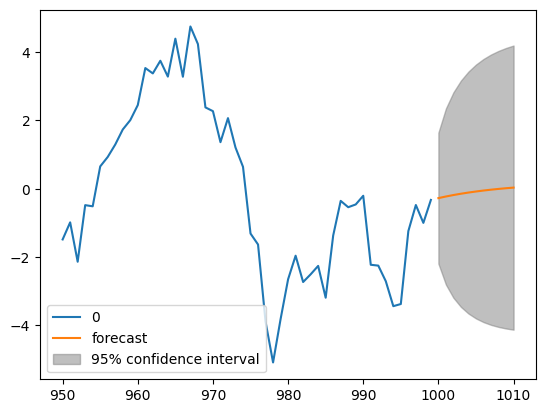

In [5]:
# Generate sample data
np.random.seed(42) # For reproducibility
n_samples = 1000

ar = np.array([1, -0.9])
ma = np.array([1])

ar_process = ArmaProcess(ar, ma)
simulated_data_1 = ar_process.generate_sample(nsample = n_samples)
simulated_data_1 = pd.DataFrame(simulated_data_1)

# Forecast the first AR(1) model
mod = ARIMA(simulated_data_1, order = (1, 0, 0))
res = mod.fit()

# Plot the data and the forecast
fig, ax = plt.subplots()
simulated_data_1.loc[950 : ].plot(ax = ax)
plot_predict(res, start = 1000, end = 1010, ax = ax)
plt.show()

C:\Users\CAguazaco\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\CAguazaco\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\CAguazaco\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\CAguazaco\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignor

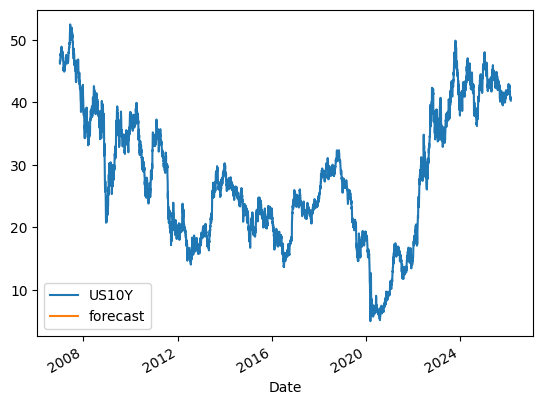

In [6]:
interest_rate_data = pd.read_csv('../Data/time_series/US10Y.csv', parse_dates = ['Date'], index_col = 'Date')

# Forecast interst rates using an AR(1) model
mod = ARIMA(interest_rate_data, order = (1, 0, 0))
res = mod.fit()

# Plot the data and the forecast
fig, ax = plt.subplots()
interest_rate_data.plot(ax = ax)
plot_predict(res, start = 0, end = '2026', alpha = None, ax = ax)
plt.show()

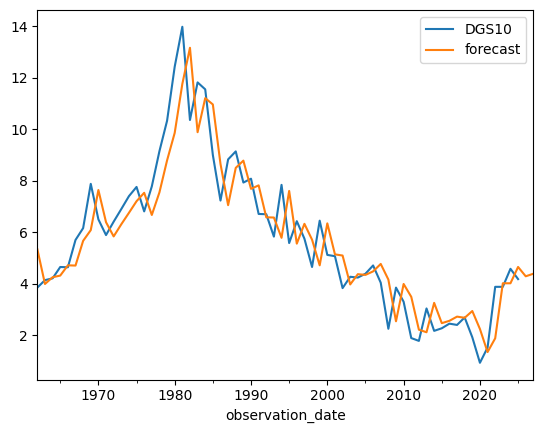

In [7]:
bonds = pd.read_csv('../Data/time_series/DGS10.csv', parse_dates = ['observation_date'], index_col = 'observation_date')

interest_rate_data = bonds.resample(rule = 'YE').last()

# Forecast interst rates using an AR(1) model
mod = ARIMA(interest_rate_data, order = [1, 0, 0])
res = mod.fit()

# Plot the data and the forecast
fig, ax = plt.subplots()
interest_rate_data.plot(ax = ax)
plot_predict(res, start = 0, end = '2027', alpha = None, ax = ax)
plt.show()

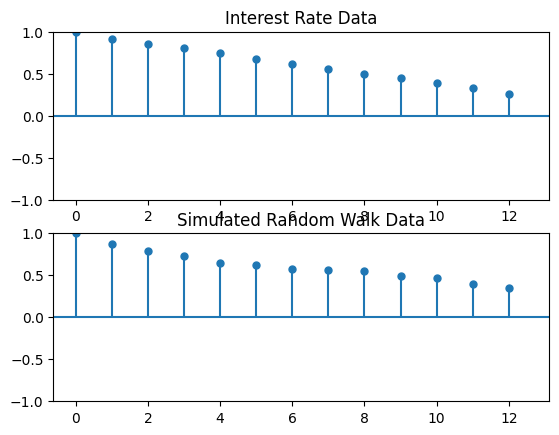

In [8]:
bonds = pd.read_csv('../Data/time_series/DGS10.csv', parse_dates = ['observation_date'], index_col = 'observation_date')

interest_rate_data = bonds.resample(rule = 'YE').last()

simulated_data = np.array([5, 4.77522278, 5.60354317, 5.96406402, 5.97965372, 
                           6.02771876, 5.5470751 , 5.19867084, 5.01867859, 5.50452928, 
                           5.89293842, 4.6220103 , 5.06137835, 5.33377592, 5.09333293, 
                           5.37389022, 4.9657092 , 5.57339283, 5.48431854, 4.68588587, 
                           5.25218625, 4.34800798, 4.34544412, 4.72362568, 4.12582912, 
                           3.54622069, 3.43999885, 3.77116252, 3.81727011, 4.35256176, 
                           4.13664247, 3.8745768 , 4.01630403, 3.71276593, 3.55672457, 
                           3.07062647, 3.45264414, 3.28123729, 3.39193866, 3.02947806, 
                           3.88707349, 4.28776889, 3.47360734, 3.33260631, 3.09729579, 
                           2.94652178, 3.50079273, 3.61020341, 4.23021143, 3.94289347, 
                           3.58422345, 3.18253962, 3.26132564, 3.19777388, 3.43527681, 
                           3.37204482])

# Plot the interest rate series and the simulated random walk series side-by-side
fig, axes = plt.subplots(2, 1)

# Plot the autocorrelation of the interest rate series in the top plot
fig = plot_acf(interest_rate_data, alpha = 1, lags = 12, ax = axes[0])

# Plot the autocorrelation of the simulated random walk series in the bottom plot
fig = plot_acf(simulated_data, alpha = 1, lags = 12, ax = axes[1])

# Label axes
axes[0].set_title("Interest Rate Data")
axes[1].set_title("Simulated Random Walk Data")
plt.show()

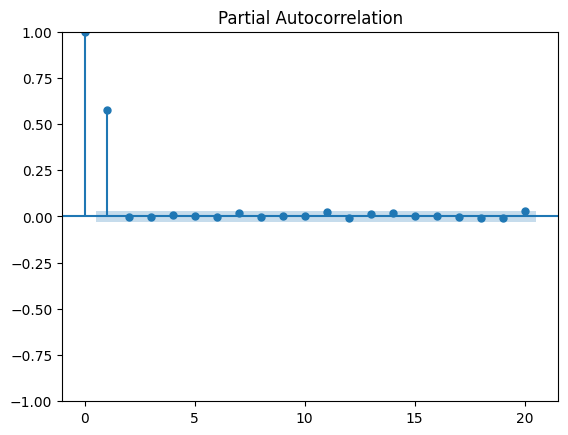

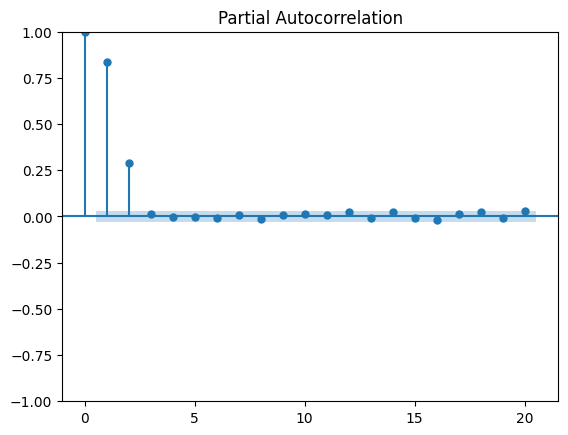

In [9]:
# Simulate AR(1) with phi=+0.6
ma = np.array([1])
ar = np.array([1, -0.6])
AR_object = ArmaProcess(ar, ma)
simulated_data_1 = AR_object.generate_sample(nsample = 5000)

# Plot PACF for AR(1)
plot_pacf(simulated_data_1, lags = 20)
plt.show()

# Simulate AR(2) with phi1=+0.6, phi2=+0.3
ma = np.array([1])
ar = np.array([1, -0.6, -0.3])
AR_object = ArmaProcess(ar, ma)
simulated_data_2 = AR_object.generate_sample(nsample = 5000)

# Plot PACF for AR(2)
plot_pacf(simulated_data_2, lags = 20)
plt.show()

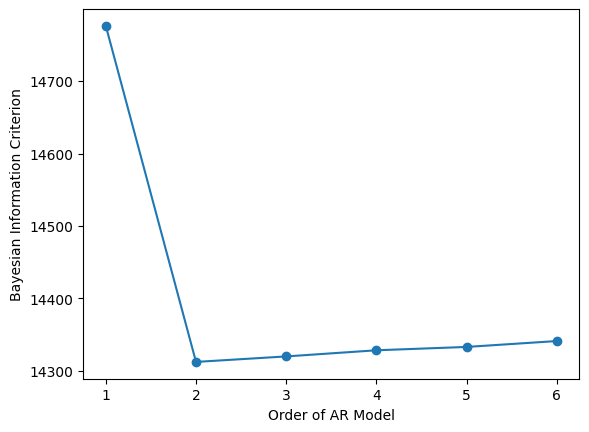

In [10]:
# Simulate AR(2) with phi1=+0.6, phi2=+0.3
ma = np.array([1])
ar = np.array([1, -0.6, -0.3])
AR_object = ArmaProcess(ar, ma)
simulated_data_2 = AR_object.generate_sample(nsample = 5000)

# Fit the data to an AR(p) for p = 0,...,6 , and save the BIC
BIC = np.zeros(7)
for p in range(7):
    mod = ARIMA(simulated_data_2, order = (p, 0, 0))
    res = mod.fit()
    
    # Save BIC for AR(p)    
    BIC[p] = res.bic
    
# Plot the BIC as a function of p
plt.plot(range(1, 7), BIC[1 : 7], marker = 'o')
plt.xlabel('Order of AR Model')
plt.ylabel('Bayesian Information Criterion')
plt.show()